<a href="https://colab.research.google.com/github/ashutosh-kedar/RT-DETR-v2-Object-Detection-Fine-Tuning/blob/main/Train_Object_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
try:
  import datasets
  import torchmetrics
  import pycocotools
except ModuleNotFoundError:
  !pip install datasets
  !pip install torchmetrics[detection]

import transformers
import numpy as np
import torch

### Loading the dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset('mrdbourke/trashify_manual_labelled_images')
dataset

In [ ]:
dataset.get('train')[0]

In [ ]:
from pprint import pprint

pprint(dataset.get('train')[0])

In [ ]:
dataset.get('train').features

In [ ]:
categories = dataset.get('train').features.get('annotations').get('category_id')
categories

In [ ]:
categories.feature.names

In [ ]:
label2id = {label:id for id,label in enumerate(categories.feature.names)}
id2label = {id:label for label,id in label2id.items()}
label2id,id2label

In [ ]:
colour_palette = {
    'bin': (0, 0, 224),         #  (red, green, blue)
    'not_bin': (255, 80, 80),
    'hand': (148, 0, 211),
    'not_hand': (255, 80, 80),
    'trash': (0, 255, 0),
    'not_trash': (255, 80, 80),
    'trash_arm': (255, 140, 0),
}

In [ ]:
sample_record = dataset.get('train')[0]

In [ ]:
import PIL
# we need this as image dimensions are too high
def half_image_dimensions(pil_image:PIL.Image):
  width, height = pil_image.size
  return pil_image.resize(size=(width//2,height//2))

In [ ]:
dataset.get('train')[0].get('image')

In [ ]:
half_image_dimensions(sample_record.get('image'))

In [ ]:
from typing import List

#when we halfed the image we also need to half the bounding box coordinated
def half_bbox(bbox):

  halfed_bbox = list()
  if isinstance(bbox, List):
    for box in bbox:
      if isinstance(box,List):
        halfed_bbox = [[index//2 for index in coordinates] for coordinates in bbox]
      else:
        halfed_bbox = [index//2 for index in bbox]

  if isinstance(bbox,torch.Tensor):
    return bbox // 2

  return halfed_bbox

In [ ]:
sample_bbox = sample_record.get('annotations').get('bbox')
sample_bbox

In [ ]:
half_bbox(sample_bbox)

### Out datset had bounding box format of 'xywh' x-cordinate y-cordinate h-heigh w-width

Ploting bounding boxes on random images from the datasets

In [ ]:
labels = categories.feature.names

In [ ]:
import random
from torchvision.ops import box_convert
import torch

from torchvision.transforms.functional import pil_to_tensor,to_pil_image
from torchvision.utils import draw_bounding_boxes

random_idx = random.randint(0,len(dataset.get('train')))


random_sample = dataset.get('train')[random_idx]

random_sampled_image = random_sample.get('image')
random_sampled_image_bbox = random_sample.get('annotations').get('bbox')

random_sampled_image = half_image_dimensions(random_sampled_image)
random_sampled_image_bbox = half_bbox(random_sampled_image_bbox)

random_sampled_image_bbox = torch.tensor(random_sampled_image_bbox)

converted_bbox = box_convert(boxes=random_sampled_image_bbox,in_fmt='xywh',out_fmt='xyxy')

random_sample_label_names = [labels[label] for label in random_sample['annotations'].get('category_id')]

random_sample_bbox_colours = [colour_palette[label] for label in random_sample_label_names]


random_sample_image_tensor = pil_to_tensor(random_sampled_image)


random_sample_image_bbox_tensor = draw_bounding_boxes(
    image=random_sample_image_tensor,
    boxes=converted_bbox,
    labels=random_sample_label_names,
    colors=random_sample_bbox_colours,
    width=3,
    font_size=25,
    fill_labels=True

)

random_sample_pil_image_bbox = to_pil_image(
    pic = random_sample_image_bbox_tensor
)

random_sample_pil_image_bbox

### Using real time detection using transformer model RT-DeTr v2 using ResNet 50 Architecture

In [ ]:
from transformers import AutoModelForObjectDetection

MODEL_NAME = 'PekingU/rtdetr_v2_r50vd'


model = AutoModelForObjectDetection.from_pretrained(
    pretrained_model_name_or_path=MODEL_NAME,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True  # if this is false it gives error as no. of labels doesnt match the no. of label the model was trained on
)

model

In [ ]:
model.class_embed   # for predicting the label for the bounding box

In [ ]:
model.bbox_embed  # for predicting the 4 co-ordinated of the bounding box.

In [ ]:
def get_model_parameters(model):

  trainable_parameters = sum([parameter_tensor.numel() for parameter_tensor in model.parameters() if parameter_tensor.requires_grad==True])
  non_trainable_parameters = sum([parameter_tensor.numel() for parameter_tensor in model.parameters() if parameter_tensor.requires_grad==False])
  total_parameters = trainable_parameters + non_trainable_parameters

  print('Trainable Parameters:',trainable_parameters)
  print('Non-Trainable parameter:',non_trainable_parameters)
  print('Total Parameters:',total_parameters)

  return {
      'trainable_parameters':trainable_parameters,
      'non_trainable_parameters':non_trainable_parameters,
      'total_parameters':total_parameters
  }

In [ ]:
model_parameter_count = get_model_parameters(model)

In [ ]:
random_sample

In [ ]:
model.forward?

In [ ]:
# model(pixel_values=random_sample['image'])

In [ ]:
# Need to preprocess the image before passing it to the model.


from transformers import AutoImageProcessor

image_preprocessor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path=MODEL_NAME,
    use_fast=True,
    do_convert_annotations=True,
    size={
        "shortest_edge":640,
        "longest_edge": 640
    },
    do_pad=True
)

In [ ]:
# random_preprocessed_image = image_preprocessor.preprocess(
#     images=random_sample.get('image'),
#     annotations=random_sample.get('annotations')

# )

In [ ]:
from pprint import pprint

random_preprocessed_image = image_preprocessor.preprocess(
    images=random_sample.get('image'),
    annotations=None,
    return_tensors='pt'
)

random_preprocessed_image.keys()

In [ ]:
print('Original image dimensions:',random_sample.get('image').size)
print('Preprocessed image dimensions:',random_preprocessed_image.pixel_values.shape)

In [ ]:
with torch.inference_mode():
  model_result = model(**random_preprocessed_image)

pprint(model_result.keys())

In [ ]:
model_result.pred_boxes.shape #  [1, 300, 4] -> (batch_size,bounding_box_predicted,4_co-ordinates)

In [ ]:
model_result.logits.shape   # [1, 300, 7] -> (batch_size,bounding_box_predicted,logints_for_7_labels)

In [ ]:
type(model_result)

In [ ]:
model_result.pred_boxes[:,0,:]

In [ ]:
random_sample

In [ ]:
from dataclasses import dataclass,asdict
from typing import List

@dataclass
class COCOAnnotation:

  image_id: int
  category_id: int
  area: float
  bbox: List[float]
  iscrowd: int

  def __post_init__(self):
    pass # validation for the data can we given here. can raise value error.



@dataclass
class EntireCOCOAnnotation:

  image_id :int
  annotations: List[COCOAnnotation]


In [ ]:
random_sample

In [ ]:
from dataclasses import asdict

def tranform_into_coco_annotation(image_annotation):

  image_id = image_annotation.get('image_id')
  category_ids = image_annotation.get('annotations').get('category_id')
  bbox = image_annotation.get('annotations').get('bbox')
  is_crowded = image_annotation.get('annotations').get('iscrowd')
  area = image_annotation.get('annotations').get('area')

  annotations = [
      {
          'image_id': image_id,
          'category_id': category_id,
          'area': area,
          'bbox': single_bbox,
          'iscrowd': is_crowd
      } for category_id,area,single_bbox,is_crowd in zip(category_ids,area,bbox,is_crowded)
  ]

  return asdict(EntireCOCOAnnotation(
      image_id=image_id,
      annotations=annotations
  ))


In [ ]:
tranform_into_coco_annotation(random_sample)

In [ ]:
preprocessed_sample_image_with_annotation = image_preprocessor.preprocess(
    images=random_sample.get('image'),
    annotations=tranform_into_coco_annotation(random_sample)
)

In [ ]:
preprocessed_sample_image_with_annotation

In [ ]:
preprocessed_sample_image_with_annotation.keys()

In [ ]:
import torch


with torch.inference_mode():
  model_result = model(**preprocessed_sample_image_with_annotation)

model_result.keys()

In [ ]:
model_result.get('logits').shape

### Need to post process to convert logits to the probability values

In [ ]:
random_sample_post_process_result = image_preprocessor.post_process_object_detection(
    outputs=model_result,
    threshold=0.5,
    target_sizes = preprocessed_sample_image_with_annotation['labels'][0]["orig_size"].unsqueeze(0)
)

In [ ]:
random_sample_post_process_result[0].keys()

In [ ]:
random_sample_post_process_result[0].get('labels'),id2label

In [ ]:
type(random_sample.get('image'))

In [ ]:
from torchvision.transforms.functional import to_pil_image, pil_to_tensor
from torchvision.utils import draw_bounding_boxes
half_image = half_image_dimensions(random_sample.get('image'))
half_bbox_coordinates = half_bbox(random_sample_post_process_result[0].get('boxes'))
# half_bbox_coordinates[0],random_sample_post_process_result[0].get('boxes')[0]

labels = [id2label[label_id.item()] for label_id in random_sample_post_process_result[0].get('labels')]

colors = [colour_palette.get(a_label) for a_label in labels]

bbox_plotted_random_sampled_image = to_pil_image(
  pic=draw_bounding_boxes(
    image=pil_to_tensor(
        pic=half_image
    ),
    boxes=half_bbox_coordinates,
    labels=labels,
    colors=colors,
    # fill = True,
    width = 3
  )
)

bbox_plotted_random_sampled_image

This is models initial prediction without training. The pipeline is as follows.

1. Random sampled image first goes through pre processing
2. Then the pre processed image is passed to the model.
3. Once the model returns the result the returned result is post processed.
4. The post processed result containing the bbox are drawn on to the image

In [ ]:
len(half_bbox_coordinates) # total number of bbox above the threshold we have in the post process
# model predicts 300 bbox. Based on our threshold the 300 bbox are filtered. Each 300 bbox predicted has a score.

Doing post process of the model result.

In [ ]:
model_result

Doing the post process manually.

Getting the scores first.



In [ ]:
import torch
THRESHOLD=0.5

sigmoid_of_logits = torch.sigmoid(model_result.logits)
flattened_sigmoid_result = torch.flatten(sigmoid_of_logits,start_dim=1)

top_100_sigmoid_values,top_100_sigmoid_values_index = torch.topk(
    input=flattened_sigmoid_result,
    k=100,
    dim=-1
)

top_100_sigmoid_values_filter = top_100_sigmoid_values > THRESHOLD

sorted_top_100_filtered_sigmoid_values,sorted_top_100_filtered_sigmoid_values_index = torch.sort(
    input= top_100_sigmoid_values[top_100_sigmoid_values_filter],
    descending=True
)

# len(sorted_top_100_filtered_sigmoid_values)
sorted_top_100_filtered_sigmoid_values

In [ ]:
random_sample_post_process_result[0].get('scores')

In [ ]:
torch.isclose(input=sorted_top_100_filtered_sigmoid_values,
               other=random_sample_post_process_result[0].get('scores'))

In [ ]:
random_sample_post_process_result[0].get('boxes').shape

In [ ]:
model_result.pred_boxes.shape

In [ ]:
len(top_100_sigmoid_values_index[0])

In [ ]:
model_result.pred_boxes.shape

In [ ]:
bboc_top_100_score_index = top_100_sigmoid_values_index[0] // total_labels
bboc_top_100_score_index

In [ ]:
from  torchvision.ops import box_convert


total_labels= len(model.config.label2id)

bboc_top_100_score_index = top_100_sigmoid_values_index[0] // total_labels

top_100_bbox = model_result.pred_boxes[0][bboc_top_100_score_index]

top_100_sorted_bbox_with_threshold = top_100_bbox[sorted_top_100_filtered_sigmoid_values_index]

#model outputs cxcywh we need to convert it to xyxy

converted_bbox_formatted = box_convert(
    boxes=top_100_sorted_bbox_with_threshold,
    in_fmt='cxcywh',
    out_fmt='xyxy'
)

# The model normalizes the coordinated. So we need to de-normalize

original_size = preprocessed_sample_image_with_annotation.get('labels')[0]['orig_size']

original_size_tensor = torch.tensor(
    [
        original_size[1],
        original_size[0],
        original_size[1],
        original_size[0],
    ]
)
# converted_bbox_formatted.shape, original_size_tensor.shape
denormalized_converted_bbox = converted_bbox_formatted * original_size_tensor # this is normal multiplication and not mat mul

# pytorch internally convert 20,4 * 4
#to
#(20,4) * (20,4) expands the 4 to 20 rows ti make multiplcation

In [ ]:
original_size_tensor

In [ ]:
denormalized_converted_bbox.shape,random_sample_post_process_result[0].get('boxes').shape

In [ ]:
torch.isclose(input=denormalized_converted_bbox,other=random_sample_post_process_result[0].get('boxes'))

In [ ]:
random_sample_post_process_result[0].get('labels')

In [ ]:

total_labels= len(model.config.label2id)

top_100_label_ids = top_100_sigmoid_values_index % total_labels

top_100_label_ids = top_100_label_ids[top_100_sigmoid_values_filter]

top_100_label_ids

In [ ]:
torch.isclose(input=top_100_label_ids,other=random_sample_post_process_result[0].get('labels'))

In [1]:
from datasets import load_dataset

HF_DATASET = 'mrdbourke/trashify_manual_labelled_images'
HF_MODEL = 'PekingU/rtdetr_v2_r50vd'

dataset_dict = load_dataset(HF_DATASET)
dataset_dict

README.md:   0%|          | 0.00/2.65k [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/334M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/348M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/345M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1128 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 1128
    })
})

In [2]:
label_names = dataset_dict.get('train').features.get('annotations').get('category_id')
label_names.feature.names

['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']

In [3]:
id2label={id:label for id,label in enumerate(label_names.feature.names)}
label2id = {label:id for id,label in id2label.items()}
id2label,label2id

({0: 'bin',
  1: 'hand',
  2: 'not_bin',
  3: 'not_hand',
  4: 'not_trash',
  5: 'trash',
  6: 'trash_arm'},
 {'bin': 0,
  'hand': 1,
  'not_bin': 2,
  'not_hand': 3,
  'not_trash': 4,
  'trash': 5,
  'trash_arm': 6})

In [4]:
from transformers import AutoModelForObjectDetection
def create_model(pretrained_model_name_or_path=HF_MODEL):
  model = AutoModelForObjectDetection.from_pretrained(
      pretrained_model_name_or_path=pretrained_model_name_or_path,
      id2label=id2label,
      label2id=label2id,
      ignore_mismatched_sizes=True
  )
  return model


model = create_model()
model;

config.json:   0%|          | 0.00/5.28k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

[transformers] RTDetrV2ForObjectDetection LOAD REPORT from: PekingU/rtdetr_v2_r50vd
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([7, 256])
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.enc_score_head.weight                         | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([7, 256])
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])         

In [5]:
original_dataset = dataset_dict.get('train')

train_test_split = original_dataset.train_test_split(test_size=0.3)
dataset_dict['train'] = train_test_split['train']
validation_test_split = train_test_split['test'].train_test_split(test_size=0.66)
dataset_dict['validation'] = validation_test_split['train']
dataset_dict['test'] = validation_test_split['test']

assert len(original_dataset) == len(dataset_dict['train']) + len(dataset_dict['validation']) + len(dataset_dict['test'])

In [6]:
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 789
    })
    validation: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 115
    })
    test: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 224
    })
})

In [7]:
from transformers import AutoProcessor

image_processor = AutoProcessor.from_pretrained(pretrained_model_name_or_path=HF_MODEL)
image_processor

preprocessor_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

RTDetrImageProcessor {
  "do_convert_annotations": true,
  "do_normalize": false,
  "do_pad": false,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "RTDetrImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 640,
    "width": 640
  }
}

In [8]:
from dataclasses import dataclass
from typing import List

@dataclass
class COCOAnnotation():
  image_id : int
  area : int
  category_id : int
  bbox : List[float]
  iscrowd : int


  def __post_init__(self):
    pass # can do validation check after the object is created


@dataclass
class SingleCOCOImage():

  image_id:int
  annotations: List[COCOAnnotation]





In [9]:
from dataclasses import asdict
def convert_to_coco_annotations(image_id,
                                area,
                                bbox,
                                category_id,
                                iscrowd):

  annotations_format = [asdict(COCOAnnotation(image_id=image_id,area=area,bbox=bbox,iscrowd=iscrowd,category_id=category_id)) for area,bbox,iscrowd,category_id in zip(area,bbox,iscrowd,category_id) ]

  return asdict(SingleCOCOImage(image_id=image_id,annotations=annotations_format))


In [10]:
random_image = dataset_dict.get('train')[0]

In [11]:
random_image

{'image': <PIL.Image.Image image mode=RGB size=960x1280>,
 'image_id': 836,
 'annotations': {'file_name': ['3a826181-9d61-4339-8a7e-1f28c1ba44e3.jpeg',
   '3a826181-9d61-4339-8a7e-1f28c1ba44e3.jpeg',
   '3a826181-9d61-4339-8a7e-1f28c1ba44e3.jpeg',
   '3a826181-9d61-4339-8a7e-1f28c1ba44e3.jpeg',
   '3a826181-9d61-4339-8a7e-1f28c1ba44e3.jpeg',
   '3a826181-9d61-4339-8a7e-1f28c1ba44e3.jpeg'],
  'image_id': [836, 836, 836, 836, 836, 836],
  'category_id': [5, 4, 0, 1, 0, 0],
  'bbox': [[364.79998779296875,
    655.7999877929688,
    215.3000030517578,
    217.1999969482422],
   [591.4000244140625,
    1064.699951171875,
    209.1999969482422,
    191.10000610351562],
   [170.6999969482422, 367.8999938964844, 468.5, 523.0999755859375],
   [478.5, 831.9000244140625, 248.6999969482422, 304.6000061035156],
   [7.0, 342.0, 356.1000061035156, 456.29998779296875],
   [649.9000244140625,
    275.3999938964844,
    300.20001220703125,
    697.4000244140625]],
  'iscrowd': [0, 0, 0, 0, 0, 0],
  'are

In [12]:
convert_to_coco_annotations(image_id = random_image.get('image_id'),
                            area=random_image.get('annotations').get('area'),
                            bbox=random_image.get('annotations').get('bbox'),
                            category_id = random_image.get('annotations').get('category_id'),
                            iscrowd=random_image.get('annotations').get('iscrowd'))

{'image_id': 836,
 'annotations': [{'image_id': 836,
   'area': 46763.16015625,
   'category_id': 5,
   'bbox': [364.79998779296875,
    655.7999877929688,
    215.3000030517578,
    217.1999969482422],
   'iscrowd': 0},
  {'image_id': 836,
   'area': 39978.12109375,
   'category_id': 4,
   'bbox': [591.4000244140625,
    1064.699951171875,
    209.1999969482422,
    191.10000610351562],
   'iscrowd': 0},
  {'image_id': 836,
   'area': 245072.34375,
   'category_id': 0,
   'bbox': [170.6999969482422, 367.8999938964844, 468.5, 523.0999755859375],
   'iscrowd': 0},
  {'image_id': 836,
   'area': 75754.0234375,
   'category_id': 1,
   'bbox': [478.5, 831.9000244140625, 248.6999969482422, 304.6000061035156],
   'iscrowd': 0},
  {'image_id': 836,
   'area': 162488.4375,
   'category_id': 0,
   'bbox': [7.0, 342.0, 356.1000061035156, 456.29998779296875],
   'iscrowd': 0},
  {'image_id': 836,
   'area': 209359.484375,
   'category_id': 0,
   'bbox': [649.9000244140625,
    275.3999938964844,


In [13]:
def preprocess_batch(examples,image_processor):
  images=[]
  annotations=[]
  for image, image_id, annotation in zip(examples.get('image'),examples.get('image_id'),examples.get('annotations')):
    images.append(image)
    annotations.append(convert_to_coco_annotations(image_id=image_id,
                                                   area=annotation.get('area'),
                                                   bbox=annotation.get('bbox'),
                                                   category_id=annotation.get('category_id'),
                                                   iscrowd=annotation.get('iscrowd')))



  preprocessed_batch = image_processor.preprocess(images=images,
                            annotations=annotations,
                            return_tensors='pt')


  return preprocessed_batch

In [14]:
from functools import partial

preprocess_fn = partial(preprocess_batch,
                        image_processor=image_processor)

In [15]:
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 789
    })
    validation: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 115
    })
    test: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 224
    })
})

In [16]:
#add preprocess function to the dataset. this will preprocess on the go
#keeping a copy of original dataset

preprocessed_dataset_dict = dataset_dict.copy()

preprocessed_dataset_dict['train'] = dataset_dict['train'].with_transform(transform=preprocess_fn)
preprocessed_dataset_dict['validation'] = dataset_dict['validation'].with_transform(transform=preprocess_fn)
preprocessed_dataset_dict['test'] = dataset_dict['test'].with_transform(transform=preprocess_fn)

preprocessed_dataset_dict

{'train': Dataset({
     features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
     num_rows: 789
 }),
 'validation': Dataset({
     features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
     num_rows: 115
 }),
 'test': Dataset({
     features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
     num_rows: 224
 })}

In [17]:
preprocessed_dataset_dict.get('train')[0]

{'pixel_values': tensor([[[0.1922, 0.2000, 0.1765,  ..., 0.3216, 0.2902, 0.2784],
          [0.1882, 0.1882, 0.1765,  ..., 0.3059, 0.2941, 0.2863],
          [0.1882, 0.1882, 0.1804,  ..., 0.2784, 0.2824, 0.2863],
          ...,
          [0.5608, 0.5098, 0.6353,  ..., 0.4118, 0.3843, 0.3843],
          [0.6039, 0.5882, 0.6667,  ..., 0.3647, 0.4196, 0.4118],
          [0.6157, 0.6627, 0.6667,  ..., 0.4039, 0.4784, 0.4078]],
 
         [[0.2314, 0.2392, 0.2157,  ..., 0.3647, 0.3373, 0.3294],
          [0.2275, 0.2275, 0.2157,  ..., 0.3529, 0.3412, 0.3373],
          [0.2275, 0.2275, 0.2196,  ..., 0.3255, 0.3294, 0.3294],
          ...,
          [0.5765, 0.5255, 0.6510,  ..., 0.4392, 0.4078, 0.4118],
          [0.6235, 0.6078, 0.6863,  ..., 0.3843, 0.4392, 0.4353],
          [0.6353, 0.6824, 0.6863,  ..., 0.4235, 0.4980, 0.4275]],
 
         [[0.2392, 0.2471, 0.2235,  ..., 0.0941, 0.0392, 0.0196],
          [0.2353, 0.2353, 0.2235,  ..., 0.0706, 0.0471, 0.0392],
          [0.2353, 0.235

In [18]:
preprocessed_dataset_dict.get('train')[0].keys()

dict_keys(['pixel_values', 'labels'])

In [19]:
from typing import List,Dict,Any
import torch

def collate_fn(preprocess_batch:List[Dict[str,Any]])->Dict[str,Any]:
  collated_data = {}

  collated_data['pixel_values'] = torch.stack([record['pixel_values'] for record in preprocess_batch])

  # Each record['labels'] is a list of one dictionary, so we extract that dictionary.
  collated_data['labels'] = [record['labels'] for record in preprocess_batch]

  return collated_data

In [20]:
#tetsing our collate function

collated_data = collate_fn(preprocessed_dataset_dict.get('train').select(range(32)))

In [21]:
type(collated_data)

dict

In [22]:
collated_data.get('pixel_values').shape, len(collated_data.get('labels'))

(torch.Size([32, 3, 640, 640]), 32)

In [23]:
# #checking how much does our model take to infer on a batch of 32
# %%time

# with torch.inference_mode():
#   model_output = model(collated_data.get('pixel_values'))

# model_output;

In [24]:
#setting up model directory
from pathlib import Path

model_dir = Path('model')

model_dir.mkdir(exist_ok=True,parents=True)

model_dir

PosixPath('model')

In [25]:
from transformers import TrainingArguments

NUM_EPOCHS = 10
BATCH_SIZE = 16
LEARINING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 0.1
WARMUP_RATIO = 0.05

THRESHOLD = 0.3

MODEL_OUTPUT_DIR = model_dir / 'rt-detr-v2-finetuned-trash-hand-bin-bbox'

training_arguments = TrainingArguments(
    output_dir=MODEL_OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARINING_RATE,
    lr_scheduler_type='linear',
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    max_grad_norm=MAX_GRAD_NORM,
    logging_strategy='epoch',
    per_device_eval_batch_size=BATCH_SIZE,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    fp16=True,
    remove_unused_columns=False,
    warmup_ratio=WARMUP_RATIO,
    eval_do_concat_batches = False
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [26]:
from transformers import Trainer
import torch

backbone_parameters = []
other_parameters = []

for name,parameters in model.model.named_parameters():
  if 'backbone' in name:
    backbone_parameters.append(parameters)
  else:
    other_parameters.append(parameters)


print(f'[INFO] No. of backbone parameters group:{len(backbone_parameters)}')
print(f'[INFO] No. of Detection head groups:{len(other_parameters)}')

BACKBONE_PARAMETERS_LR = 1e-5
DETECTION_HEAD_LR = 1e-4
# based on RT-DETR v2 paper


class CustomTrainer(Trainer):

  def create_optimizer(self):
    self.optimizer =  torch.optim.AdamW([
        {'params':backbone_parameters,'lr':BACKBONE_PARAMETERS_LR},
        {'params':other_parameters,'lr':DETECTION_HEAD_LR}
    ],weight_decay=0.0001)
    return self.optimizer



[INFO] No. of backbone parameters group:55
[INFO] No. of Detection head groups:363


In [27]:
import torch
from dataclasses import dataclass

@dataclass
class ModelOutput:
  logits: torch.tensor
  pred_boxes: torch.tensor

In [28]:
from torchvision.ops import box_convert

def convert_bbox_format_fn(
    bbox,
    in_format,
    out_format,
    image_original_size
):
  # print(f'[INFO] In-Format {in_format} Out-Format {out_format}')
  converted_bbox = box_convert(
      boxes=bbox,
      in_fmt=in_format,
      out_fmt=out_format,
  )
  # print(f'[INFO] Denormalizing the bbox.')

  image_height = image_original_size[0]
  image_width = image_original_size[1]

  de_normalized_bbox = converted_bbox * torch.tensor([image_width,image_height,image_width,image_height])
  # Multiplying x co-ordinate with width and y with height

  return de_normalized_bbox

In [29]:
pred_test = []

In [30]:
!pip install torchmetrics[detection]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.0 MB/s eta 0:00:00


In [31]:
import numpy as np
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision

@torch.no_grad()
def compute_metrics(
    eval_predict,
    convert_bbox_format_fn,
    threshold,
    image_processor,
    id2label
):
  predictions,targets = eval_predict.predictions,eval_predict.label_ids

  # print('len(predictions)',len(predictions))
  # print('len(target)',len(targets))
  # print('len(predictions[0])',len(predictions[0]))
  # print('len(target[0])',len(targets[0]))

  image_sizes = []
  post_processed_targets = []
  post_processed_prediction = []


  for batch in targets:

    batch_image_sizes = torch.tensor(np.array([record.get('orig_size') for record in batch]))
    # print('len(batch_image_sizes)',len(batch_image_sizes))
    image_sizes.append(batch_image_sizes)

    for record in batch:

      boxes = torch.tensor(record.get('boxes'))
      # print('boxes',boxes.shape)
      converted_boxes = convert_bbox_format_fn(bbox=boxes,
                                            in_format='cxcywh',
                                            out_format='xyxy',
                                            image_original_size=record.get('orig_size'))

      labels = torch.tensor(record.get('class_labels'))

      post_processed_targets.append({
          "boxes":converted_boxes,
          "labels":labels
      })

  # print('len(image_sizes):',len(image_sizes))
  # print('[INFO] post_processed_targets:',len(post_processed_targets))

  for pred_batch,target_sizes in zip(predictions,image_sizes):

    loss,logits,bbox = pred_batch[0],pred_batch[1],pred_batch[2]

    # print('loss shape:',torch.tensor(logits).shape)
    model_output = ModelOutput(logits=torch.tensor(logits),
                               pred_boxes=torch.tensor(bbox))

    post_processed_model_output = image_processor.post_process_object_detection(
        outputs=model_output,
        threshold=threshold,
        target_sizes=target_sizes
    )
    post_processed_prediction.extend(post_processed_model_output)

  # print(f'[INFO] post_processed_prediction:',len(post_processed_prediction))

  max_detection_threshold = [1,10,100]
  metric = MeanAveragePrecision(box_format='xyxy',
                       max_detection_thresholds=max_detection_threshold,
                       class_metrics=True)

  metric.update(post_processed_prediction,post_processed_targets)

  metrics = metric.compute()
  classes = metrics.pop('classes')
  map_per_class = metrics.pop('map_per_class')
  mar_per_class = metrics.pop('mar_100_per_class')

  for class_id,class_map,class_mar in zip(classes,map_per_class,mar_per_class):

    class_name = id2label.get(class_id.item())
    metrics[f'map_{class_name}'] = class_map
    metrics[f'mar_{class_name}'] = class_mar

  metrics = {key:round(value.item(),2) for key, value in metrics.items()}

  return metrics


In [32]:
from functools import partial

metrics = partial(
    compute_metrics,
    convert_bbox_format_fn=convert_bbox_format_fn,
    threshold=0.0,
    image_processor=image_processor,
    id2label=id2label
)

In [33]:


trainer = CustomTrainer(
    model=model,
    args=training_arguments,
    data_collator=collate_fn,
    train_dataset=preprocessed_dataset_dict['train'],
    eval_dataset=preprocessed_dataset_dict['validation'],
    compute_metrics=metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map Bin,Mar Bin,Map Hand,Mar Hand,Map Not Bin,Mar Not Bin,Map Not Hand,Mar Not Hand,Map Not Trash,Mar Not Trash,Map Trash,Mar Trash,Map Trash Arm,Mar Trash Arm
1,81.864395,17.970444,0.150000,0.210000,0.170000,0.000000,0.040000,0.160000,0.250000,0.380000,0.470000,0.000000,0.240000,0.490000,0.500000,0.850000,0.380000,0.840000,0.000000,0.170000,0.000000,0.000000,0.010000,0.480000,0.160000,0.790000,0.000000,0.130000
2,25.141682,10.806190,0.390000,0.540000,0.430000,0.010000,0.150000,0.400000,0.420000,0.610000,0.660000,0.300000,0.450000,0.680000,0.720000,0.870000,0.580000,0.820000,0.010000,0.740000,0.000000,0.000000,0.110000,0.550000,0.610000,0.810000,0.700000,0.800000
3,18.369043,9.597543,0.410000,0.570000,0.500000,0.010000,0.180000,0.430000,0.450000,0.680000,0.730000,0.300000,0.560000,0.750000,0.750000,0.880000,0.580000,0.830000,0.020000,0.770000,0.000000,0.350000,0.180000,0.600000,0.660000,0.830000,0.710000,0.870000
4,16.044138,9.228659,0.440000,0.590000,0.510000,0.010000,0.200000,0.450000,0.480000,0.700000,0.750000,0.400000,0.580000,0.760000,0.760000,0.880000,0.550000,0.810000,0.010000,0.800000,0.010000,0.450000,0.210000,0.610000,0.690000,0.830000,0.820000,0.870000
5,14.634399,9.127348,0.450000,0.590000,0.520000,0.040000,0.200000,0.460000,0.460000,0.700000,0.740000,0.300000,0.590000,0.750000,0.750000,0.880000,0.570000,0.820000,0.010000,0.700000,0.020000,0.450000,0.250000,0.630000,0.690000,0.830000,0.820000,0.900000
6,13.604175,9.092944,0.420000,0.600000,0.460000,0.010000,0.210000,0.440000,0.500000,0.690000,0.730000,0.100000,0.570000,0.750000,0.760000,0.880000,0.560000,0.800000,0.010000,0.750000,0.080000,0.400000,0.220000,0.610000,0.690000,0.820000,0.630000,0.870000
7,12.819586,9.164296,0.430000,0.610000,0.460000,0.010000,0.210000,0.440000,0.490000,0.690000,0.730000,0.100000,0.570000,0.740000,0.760000,0.880000,0.550000,0.800000,0.010000,0.720000,0.100000,0.400000,0.220000,0.610000,0.690000,0.820000,0.650000,0.870000
8,12.227703,9.092342,0.450000,0.610000,0.530000,0.080000,0.200000,0.460000,0.500000,0.680000,0.730000,0.200000,0.580000,0.740000,0.760000,0.880000,0.550000,0.790000,0.010000,0.710000,0.100000,0.400000,0.230000,0.620000,0.690000,0.820000,0.780000,0.900000
9,11.752263,9.150928,0.440000,0.610000,0.530000,0.050000,0.200000,0.460000,0.490000,0.690000,0.720000,0.200000,0.580000,0.730000,0.750000,0.880000,0.550000,0.780000,0.010000,0.670000,0.100000,0.400000,0.220000,0.620000,0.690000,0.820000,0.780000,0.870000
10,11.507751,9.169146,0.450000,0.620000,0.540000,0.050000,0.200000,0.470000,0.510000,0.680000,0.730000,0.200000,0.610000,0.740000,0.750000,0.880000,0.550000,0.780000,0.010000,0.700000,0.180000,0.450000,0.210000,0.610000,0.690000,0.820000,0.780000,0.870000


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.aifi.0.layers.0.self_attn.k_proj.weight', 'model.encoder.aifi.0.layers.0.self_attn.k_proj.bias', 'model.encoder.aifi.0.layers.0.self_attn.v_proj.weight', 'model.encoder.aifi.0.layers.0.self_attn.v_proj.bias', 'model.encoder.aifi.0.layers.0.self_attn.q_proj.weight', 'model.encoder.aifi.0.layers.0.self_attn.q_proj.bias', 'model.encoder.aifi.0.layers.0.self_attn.o_proj.weight', 'model.encoder.aifi.0.layers.0.self_attn.o_proj.bias', 'model.encoder.aifi.0.layers.0.self_attn_layer_norm.weight', 'model.encoder.aifi.0.layers.0.self_attn_layer_norm.bias', 'model.encoder.aifi.0.layers.0.mlp.fc1.weight', 'model.encoder.aifi.0.layers.0.mlp.fc1.bias', 'model.encoder.aifi.0.layers.0.mlp.fc2.weight', 'model.encoder.aifi.0.layers.0.mlp.fc2.bias', 'model.encoder.aifi.0.layers.0.final_layer_norm.weight', 'model.encoder.aifi.0.layers.0.final_layer_norm.bias', 'model.decoder.layers.0.self_attn.o_proj.weight', 'model.dec

TrainOutput(global_step=500, training_loss=21.796513549804686, metrics={'train_runtime': 1043.3257, 'train_samples_per_second': 7.562, 'train_steps_per_second': 0.479, 'total_flos': 2.486205097648128e+18, 'train_loss': 21.796513549804686, 'epoch': 10.0})

In [34]:
trainer.save_model(MODEL_OUTPUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [35]:
trainer.push_to_hub(commit_message='FineTuned RT-DETR for bbox prediction on trash, bin and hand')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...in-bbox/model.safetensors:   0%|          | 77.6kB /  172MB            

  ...in-bbox/training_args.bin:  10%|#         |   542B / 5.20kB            

CommitInfo(commit_url='https://huggingface.co/ashutosh-kedar/rt-detr-v2-finetuned-trash-hand-bin-bbox/commit/1a8eab90cb4de20ad12fa3fc7f6748fb5dd625cb', commit_message='FineTuned RT-DETR for bbox prediction on trash, bin and hand', commit_description='', oid='1a8eab90cb4de20ad12fa3fc7f6748fb5dd625cb', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ashutosh-kedar/rt-detr-v2-finetuned-trash-hand-bin-bbox', endpoint='https://huggingface.co', repo_type='model', repo_id='ashutosh-kedar/rt-detr-v2-finetuned-trash-hand-bin-bbox'), pr_revision=None, pr_num=None)

In [36]:
# from huggingface_hub import create_repo
# create_repo(
#     "ashutosh-kedar/rt-detr-v2-finetuned",
#     exist_ok=True
# )
# trainer.args.hub_model_id = repo_id

# trainer.push_to_hub(
#     commit_message='FineTuned RT-DETR for bbox prediction on trash, bin and hand',
# )

In [37]:
print(trainer.args.hub_model_id)

None


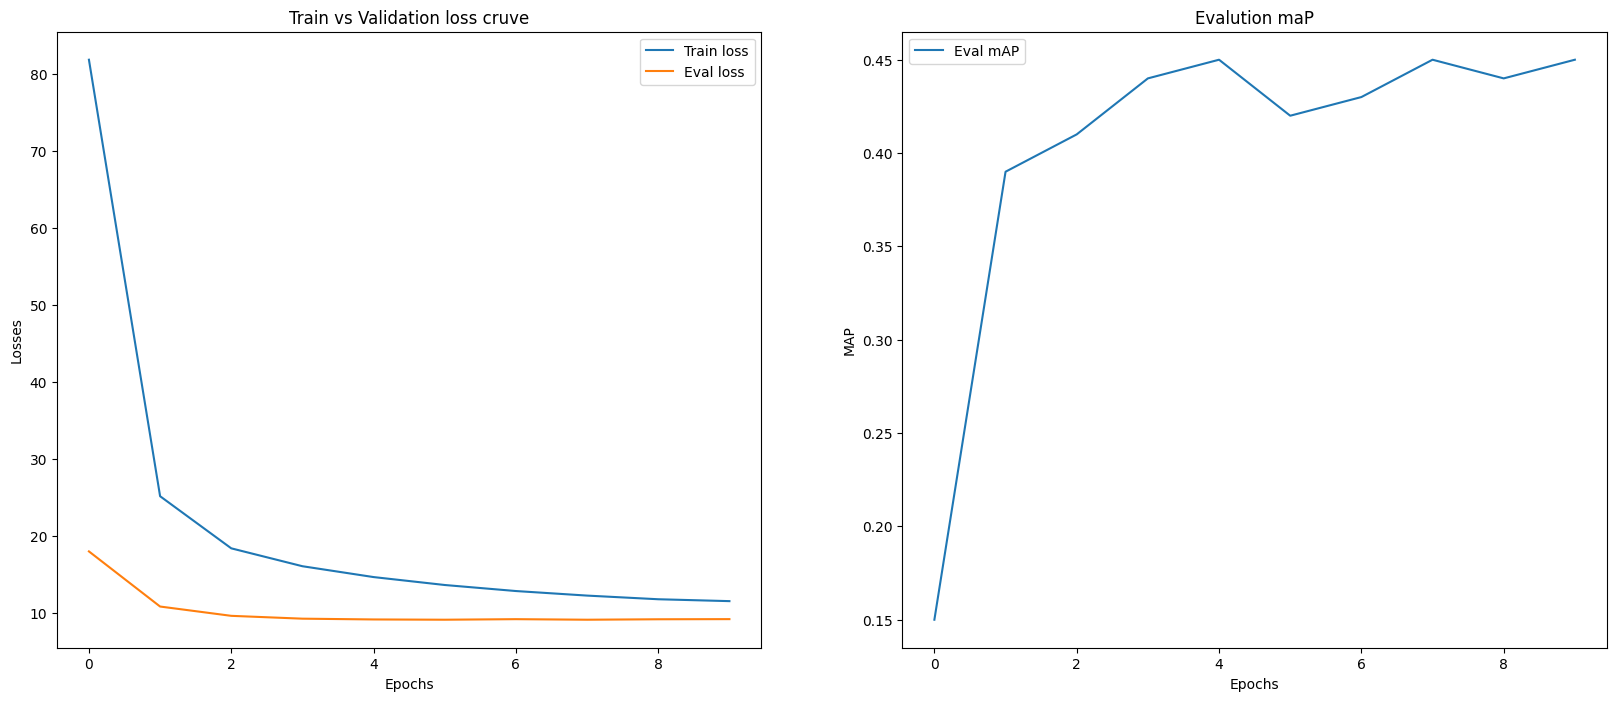

In [38]:
from matplotlib import pyplot as plt


log_history = trainer.state.log_history

train_loss = [item['loss'] for item in log_history if 'loss' in item.keys()]
eval_loss =  [item['eval_loss'] for item in log_history if 'eval_loss' in item.keys() ]

eval_map = [item['eval_map'] for item in log_history if 'eval_map' in item.keys()]

fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(20,8))
ax[0].plot(train_loss,label='Train loss')
ax[0].plot(eval_loss,label='Eval loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Losses')
ax[0].set_title('Train vs Validation loss cruve')
ax[0].legend()

ax[1].plot(eval_map,label='Eval mAP')
ax[1].set_title('Evalution maP')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('MAP')
ax[1].legend()

In [39]:
preprocessed_dataset_dict

{'train': Dataset({
     features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
     num_rows: 789
 }),
 'validation': Dataset({
     features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
     num_rows: 115
 }),
 'test': Dataset({
     features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
     num_rows: 224
 })}

In [40]:
test_data_preds = trainer.predict(test_dataset=preprocessed_dataset_dict.get('test'))

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


In [41]:
predictions_output = test_data_preds.predictions
label_ids_output = test_data_preds.label_ids
type(predictions_output),type(label_ids_output)

(list, list)

In [42]:
len(predictions_output) # is equal to num of batches.

14

In [43]:
test_batch_metrics = predictions_output[0][0]
test_batch_logits = predictions_output[0][1]
test_batch_bbox = predictions_output[0][2]

print(f'Test batchs logits output shape {test_batch_logits.shape}')
print(f'Test batchs bbox shape {test_batch_bbox.shape}')
#RT-DETR predicts 300 bounding boxes

Test batchs logits output shape (16, 300, 7)
Test batchs bbox shape (16, 300, 4)


In [44]:
test_batch_logits = []
test_batch_bbox = []


for test_pred_batch in predictions_output:
  test_batch_logits.append(test_pred_batch[1])
  test_batch_bbox.append(test_pred_batch[2])


print(f'Before concatenating logits size : {len(test_batch_logits)}')
print(f'Before concatenating bbox size : {len(test_batch_bbox)}')

test_batch_logits = torch.tensor(np.concatenate(test_batch_logits))
test_batch_bbox = torch.tensor(np.concatenate(test_batch_bbox))

print(f'After concatenating logits tensor shape {test_batch_logits.shape}')
print(f'After concatenating bbox tensor shape {test_batch_bbox.shape}')

Before concatenating logits size : 14
Before concatenating bbox size : 14
After concatenating logits tensor shape torch.Size([224, 300, 7])
After concatenating bbox tensor shape torch.Size([224, 300, 4])


In [45]:
test_dataset_pred_dict = []


for i in range(len(test_batch_bbox)):

  test_logits = test_batch_logits[i].unsqueeze(0)
  test_bbox = test_batch_bbox[i].unsqueeze(0)

  original_size = preprocessed_dataset_dict.get('test')[i]['labels']['orig_size'].unsqueeze(0)

  model_pred_output = ModelOutput(
      logits=test_logits,
      pred_boxes=test_bbox
  )
  post_process_object_detection = image_processor.post_process_object_detection(
      outputs = model_pred_output,
      threshold=0.0,
      target_sizes = original_size
  )

  test_dataset_pred_dict.append({
      "boxes" : post_process_object_detection[0]['boxes'],
      "labels" : post_process_object_detection[0]['labels'],
      "scores" : post_process_object_detection[0]['scores'],
  })


print(f'[INFO] No of prediction examples: {len(test_dataset_pred_dict)}')

[INFO] No of prediction examples: 224


In [46]:
preprocessed_dataset_dict.get('test')[0]['labels']

{'size': tensor([640, 640]), 'image_id': tensor([774]), 'class_labels': tensor([0, 5, 1]), 'boxes': tensor([[0.5253, 0.4603, 0.3507, 0.4313],
        [0.5142, 0.5794, 0.1516, 0.1244],
        [0.3863, 0.7096, 0.2869, 0.2479]]), 'area': tensor([61952.8047,  7721.2002, 29128.1406]), 'iscrowd': tensor([0, 0, 0]), 'orig_size': tensor([1280,  960])}

In [47]:
test_dataset_target_dict =  []

for item in preprocessed_dataset_dict.get('test'):
  sample_labels = item.get('labels')
  original_size = sample_labels['orig_size']

  true_labels = sample_labels['class_labels']

  bbox = sample_labels['boxes']

  converted_bbox = convert_bbox_format_fn(bbox=bbox,
                                            in_format='cxcywh',
                                            out_format='xyxy',
                                            image_original_size=original_size)


  test_dataset_target_dict.append({
      'labels':true_labels,
      'boxes':converted_bbox
  })

print(f'[INFO] No of prediction examples: {len(test_dataset_target_dict)}')

[INFO] No of prediction examples: 224


In [48]:
!pip install torchmetrics

In [49]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

metrics = MeanAveragePrecision(iou_type='bbox',
                     class_metrics=True)
metrics.update(
    preds = test_dataset_pred_dict,
    target = test_dataset_target_dict
)

metrics_result = metrics.compute()

In [50]:
map_per_class = metrics_result.pop('map_per_class')
mar_100_per_class = metrics_result.pop('mar_100_per_class')
classes = metrics_result.pop('classes')
metrics_result

{'map': tensor(0.3957),
 'map_50': tensor(0.5523),
 'map_75': tensor(0.4524),
 'map_small': tensor(0.),
 'map_medium': tensor(0.1722),
 'map_large': tensor(0.4102),
 'mar_1': tensor(0.4815),
 'mar_10': tensor(0.6937),
 'mar_100': tensor(0.7334),
 'mar_small': tensor(0.),
 'mar_medium': tensor(0.5108),
 'mar_large': tensor(0.7552)}

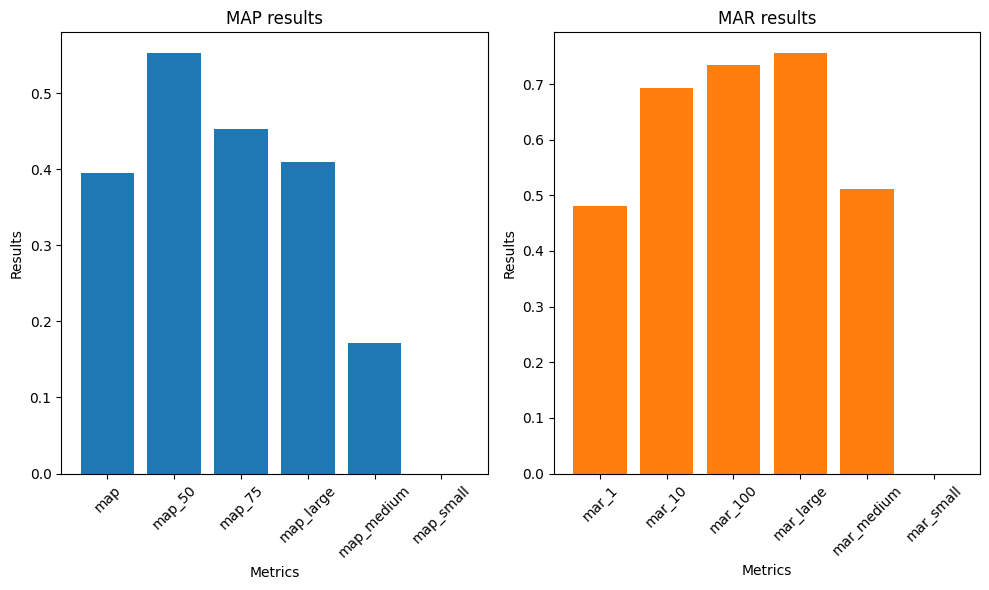

In [55]:
from matplotlib import pyplot as plt


test_map_results = {key:value for key,value in metrics_result.items() if 'map' in key}
test_mar_results = {key:value for key,value in metrics_result.items() if 'mar' in key}

test_map_labels,test_map_values = zip(*sorted(test_map_results.items()))
test_mar_labels,test_mar_values = zip(*sorted(test_mar_results.items()))

fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(10,6))


ax[0].bar(test_map_labels,test_map_values)
ax[0].set_xlabel('Metrics')
ax[0].set_ylabel('Results')
ax[0].set_title('MAP results')
ax[0].tick_params(axis='x',rotation=45)

ax[1].bar(test_mar_labels,test_mar_values,color='tab:orange')
ax[1].set_xlabel('Metrics')
ax[1].set_ylabel('Results')
ax[1].set_title('MAR results')
ax[1].tick_params(axis='x',rotation=45)

plt.tight_layout()

In [56]:
color_palette = {
    'bin': (0, 0, 224),         # Bright Blue (High contrast with greenery) in format (red, green, blue)
    'not_bin': (255, 80, 80),   # Light Red to indicate negative class

    'hand': (148, 0, 211),      # Dark Purple (Contrasts well with skin tones)
    'not_hand': (255, 80, 80),  # Light Red to indicate negative class

    'trash': (0, 255, 0),       # Bright Green (For trash-related items)
    'not_trash': (255, 80, 80), # Light Red to indicate negative class

    'trash_arm': (255, 140, 0), # Deep Orange (Highly visible)
}

def normalize_rgb(rgb_values):
  return tuple(x/255 for x in rgb_values)


Text(0.5, 1.0, 'MAR(Mean average recall)')

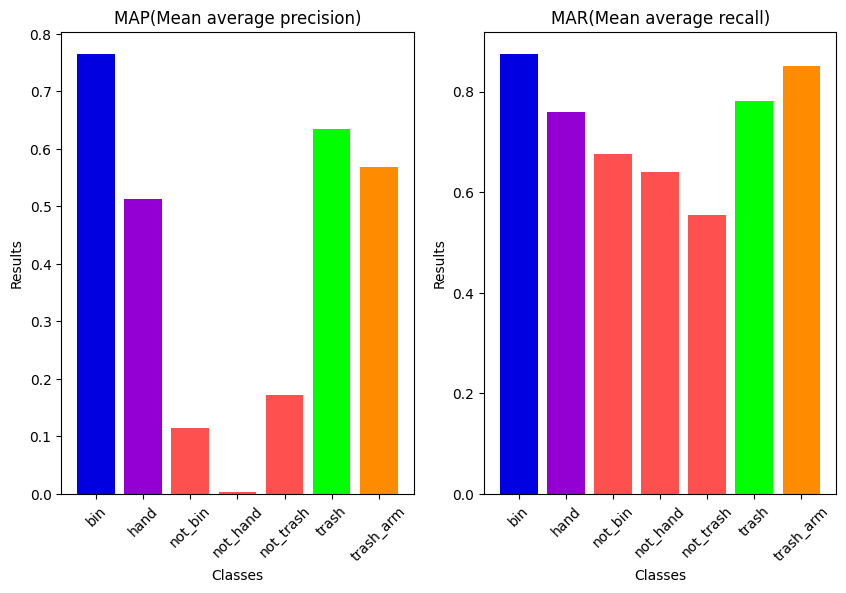

In [62]:
from matplotlib import pyplot as plt

map_per_class_dict = dict(zip(list(label2id.keys()),map_per_class))
mar_per_class_dict = dict(zip(list(label2id.keys()),mar_100_per_class))

map_per_class_labels,map_per_class_values = zip(*sorted(map_per_class_dict.items()))
mar_per_class_labels,mar_per_class_values = zip(*sorted(mar_per_class_dict.items()))

normalized_color_palette = {label_name:normalize_rgb(color) for label_name,color in color_palette.items()}

color_for_map = [normalized_color_palette.get(label) for label in map_per_class_labels]
color_for_mar = [normalized_color_palette.get(label) for label in mar_per_class_labels]

fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(10,6))

ax[0].bar(map_per_class_labels,map_per_class_values,color=color_for_map)
ax[0].set_xlabel('Classes')
ax[0].set_ylabel('Results')
ax[0].tick_params(axis='x',rotation=45)
ax[0].set_title('MAP(Mean average precision)')

ax[1].bar(mar_per_class_labels,mar_per_class_values,color=color_for_mar)
ax[1].set_xlabel('Classes')
ax[1].set_ylabel('Results')
ax[1].tick_params(axis='x',rotation=45)
ax[1].set_title('MAR(Mean average recall)')




In [94]:
from typing import List
import PIL

#when we halfed the image we also need to half the bounding box coordinated
def half_bbox(bbox):

  halfed_bbox = list()
  if isinstance(bbox, List):
    for box in bbox:
      if isinstance(box,List):
        halfed_bbox = [[index//2 for index in coordinates] for coordinates in bbox]
      else:
        halfed_bbox = [index//2 for index in bbox]

  if isinstance(bbox,torch.Tensor):
    return bbox // 2

  return halfed_bbox


# we need this as image dimensions are too high
def half_image_dimensions(pil_image:PIL.Image):
  width, height = pil_image.size
  return pil_image.resize(size=(width//2,height//2))

[INFO] Total time take for inference 0.06 secs


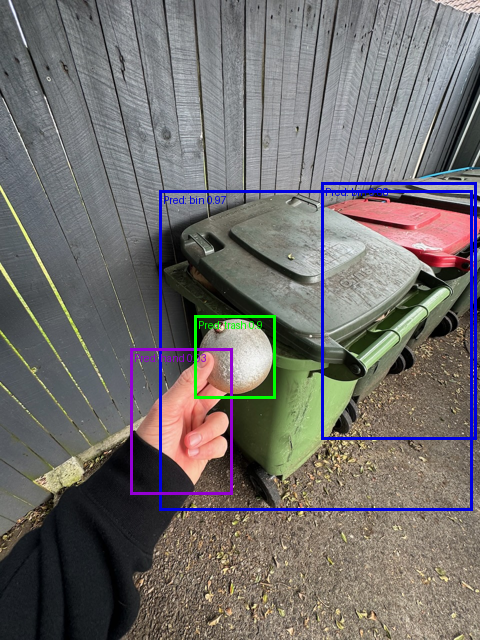

In [110]:
import random
import time
import torch
from torchvision.transforms.functional import pil_to_tensor
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image

random_idx = random.randint(0,len(preprocessed_dataset_dict.get('train')))


random_sample  = preprocessed_dataset_dict.get('train')[random_idx]

start_time  = time.time()

with torch.inference_mode():
  random_sample_model_output = model(pixel_values=random_sample.get('pixel_values').unsqueeze(0).to('cuda'),pixel_mask=None)

end_time = time.time()

print(f'[INFO] Total time take for inference {round((end_time-start_time),2)} secs')


random_sample_post_processed = image_processor.post_process_object_detection(
    outputs=random_sample_model_output,
    threshold=0.3,
    target_sizes=random_sample.get('labels').get('orig_size').unsqueeze(0)
)



random_sample_post_processed_scores = random_sample_post_processed[0].get('scores')
random_sample_post_processed_labels = random_sample_post_processed[0].get('labels')
random_sample_post_processed_boxes =  half_bbox(random_sample_post_processed[0].get('boxes'))

#pred label score

random_pred_label_score = [f'Pred: {id2label.get(label_id.item())} {round(score.item(),2)}' for label_id,score in zip(random_sample_post_processed_labels,random_sample_post_processed_scores)]
random_pred_color = [color_palette.get(id2label.get(label_id.item())) for label_id in random_sample_post_processed_labels]

test_pred_image_result = to_pil_image(
    pic = draw_bounding_boxes(
            image = pil_to_tensor(pic=half_image_dimensions(dataset_dict['train'][random_idx].get('image'))),
            boxes = random_sample_post_processed_boxes,
            labels = random_pred_label_score,
            colors = random_pred_color,
            width = 3,
          )
)

test_pred_image_result



In [ ]:
def convert_bbox_format_fn(
    bbox,
    in_format,
    out_format,
    image_original_size
):
  pass

[INFO] Before converting bbox:tensor([[0.3823, 0.6599, 0.2115, 0.2305],
        [0.4889, 0.5581, 0.1705, 0.1268],
        [0.6383, 0.5486, 0.6157, 0.5055],
        [0.8295, 0.4769, 0.3237, 0.3629]])
[INFO] After converting from cxcywh to xyxy tensor([[ 265.5000,  697.2000,  468.5000,  992.2000],
        [ 387.5000,  633.2000,  551.2001,  795.4999],
        [ 317.2000,  378.7000,  908.2999, 1025.8000],
        [ 640.9000,  378.2000,  951.7001,  842.7001]])
[INFO] Halfed converted bbox tensor([[132., 348., 234., 496.],
        [193., 316., 275., 397.],
        [158., 189., 454., 512.],
        [320., 189., 475., 421.]])


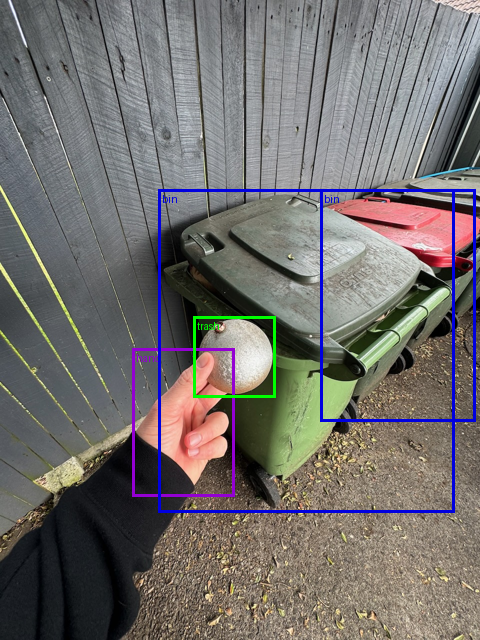

In [130]:
from torchvision.transforms.functional import pil_to_tensor
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image

ground_truth_image = half_image_dimensions(dataset_dict.get('train')[random_idx].get('image'))
print(f'[INFO] Before converting bbox:{random_sample.get('labels').get('boxes')}')
converted_bbox = convert_bbox_format_fn(
    bbox = random_sample.get('labels').get('boxes'),
    in_format='cxcywh',
    out_format='xyxy',
    image_original_size=random_sample.get('labels').get('orig_size')
)
print(f'[INFO] After converting from cxcywh to xyxy {converted_bbox}')
converted_half_boxes = half_bbox(converted_bbox)

print(f'[INFO] Halfed converted bbox {converted_half_boxes}')

random_sample_ground_truth_labels = [id2label.get(label_id.item()) for label_id in random_sample.get('labels').get('class_labels')]
random_sample_ground_truth_colors = [color_palette.get(label_name) for label_name in random_sample_ground_truth_labels]

ground_truth_image_bbox = to_pil_image(
  pic = draw_bounding_boxes(
          image = pil_to_tensor(pic=half_image_dimensions(dataset_dict.get('train')[random_idx].get('image'))),
          boxes = converted_half_boxes,
          labels = random_sample_ground_truth_labels,
          colors = random_sample_ground_truth_colors,
          width = 3
        )
)


ground_truth_image_bbox

(np.float64(-0.5), np.float64(479.5), np.float64(639.5), np.float64(-0.5))

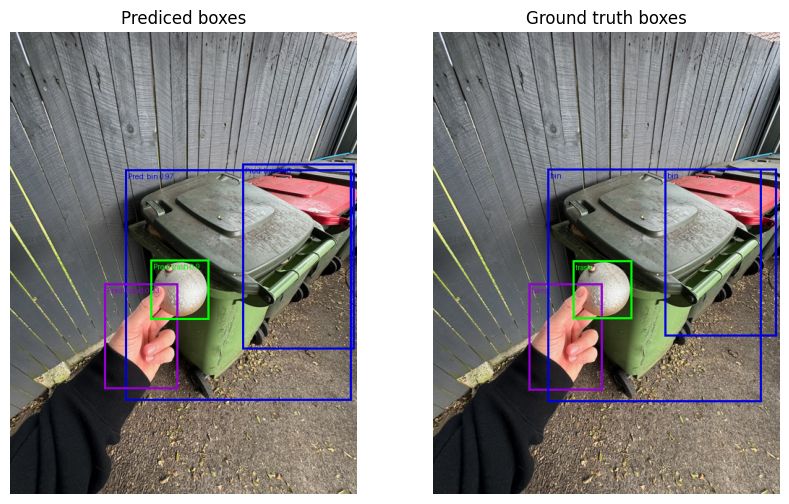

In [136]:
#comapring side by side
from matplotlib import pyplot as plt

fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(10,6))

ax[0].imshow(test_pred_image_result)
ax[0].set_title('Prediced boxes')
ax[0].axis(False)

ax[1].imshow(ground_truth_image_bbox)
ax[1].set_title('Ground truth boxes')
ax[1].axis(False)

In [137]:
trainer.processing_class = image_processor

In [138]:
HF_model_hub_url = trainer.push_to_hub(
    commit_message='Added image processor'
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...in-bbox/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...in-bbox/model.safetensors:  47%|####6     | 79.9MB /  172MB            

In [139]:
HF_model_hub_url

CommitInfo(commit_url='https://huggingface.co/ashutosh-kedar/rt-detr-v2-finetuned-trash-hand-bin-bbox/commit/89666da23a66f6327e7626e93c2742fa32a105f3', commit_message='Added image processor', commit_description='', oid='89666da23a66f6327e7626e93c2742fa32a105f3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ashutosh-kedar/rt-detr-v2-finetuned-trash-hand-bin-bbox', endpoint='https://huggingface.co', repo_type='model', repo_id='ashutosh-kedar/rt-detr-v2-finetuned-trash-hand-bin-bbox'), pr_revision=None, pr_num=None)

In [55]:
from pathlib import Path

gradio_demo_files_path = Path('./demo/object_detection')

gradio_demo_files_path.mkdir(exist_ok=True,parents=True)

In [56]:
%%writefile ./demo/object_detection/app.py

from transformers import AutoImageProcessor
from transformers import AutoModelForObjectDetection
import torch
from PIL import ImageDraw, ImageFont
import gradio as gr


HF_MODEL_PATH = 'ashutosh-kedar/rt-detr-v2-finetuned-trash-hand-bin-bbox'


image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path=HF_MODEL_PATH
)

hf_model = AutoModelForObjectDetection.from_pretrained(
    pretrained_model_name_or_path=HF_MODEL_PATH
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
hf_model.to(device)


color_dict = {
    "bin": "green",
    "trash": "blue",
    "hand": "purple",
    "trash_arm": "yellow",
    "not_trash": "red",
    "not_bin": "red",
    "not_hand": "red",
}

id2label = hf_model.config.id2label


def predict_image_bbox(image,threshold):

  hf_model.eval()

  with torch.inference_mode():

    preprocessed_image = image_processor(images=[image],return_tensors='pt')
    model_result = hf_model(**preprocessed_image.to(device))

    target_size = torch.tensor([[image.size[1],image.size[0]]])  #  [batch_size, height, width]

    post_process_result = image_processor.post_process_object_detection(
        outputs=model_result,
        threshold=threshold,
        target_sizes=target_size
    )[0]


  for key,value in post_process_result.items():
    try:
      post_process_result[key] = value.item().cpu()
    except:
      post_process_result[key] = value.cpu()


  draw = ImageDraw.Draw(image)
  font = ImageFont.load_default(size=20)

  detected_class_text = []
  for label,bbox,score in zip(post_process_result['labels'],post_process_result['boxes'],post_process_result['scores']):
    x1,y1,x2,y2 = tuple(bbox.tolist())
    label_name = id2label.get(label.item())
    color = color_dict.get(label_name)

    detected_class_text.append(label_name)

    draw.rectangle(xy=(x1,y1,x2,y2),
                   outline=color,
                   width=3)

    label_string_to_show  = f'Pred: {label_name} {round(score.item(),2)}'

    draw.text(xy=(x1,y1),
              text=label_string_to_show,
              fill='white',
              font=font
              )

  del draw

  target_item = {"trash", "bin", "hand"}
  detected_item = set(detected_class_text)

  if not detected_item & target_item:
    return_string = (f'No trash bin or hand detected at confidence threshold ({threshold})', f'Try increasing the threshold or try another image')

    return image,return_string

  missing_item = target_item - detected_item
  if missing_item:
    return_string = (f'Detected the following items: {detected_item & target_item}. But missing the following items {missing_item}',
                     f'Try increasing the treshold and if still didnt get the item, the model needs to be updated with more data ;)')

    return image,return_string

  return_string = f'Found the following items: {detected_item}, Keep going!'

  return image,return_string


description = """
Detect **trash**, **hands**, and **bins** in images using a fine-tuned **RT-DETR v2** object detection model.
This model is a fine-tuned version of **RT-DETR v2** trained on a custom dataset containing three object classes: **Trash**, **Hand**, and **Bin**.

"""


demo = gr.Interface(
    fn=predict_image_bbox,
    inputs=[
        gr.Image(type='pil',label="Target Image"),
        gr.Slider(minimum=0,maximum=1,value=0.3,label="Confidence Threshold")
    ],
    outputs=[
        gr.Image(type='pil',label='Output Image'),
        gr.Text(label='Text Output')
    ],
    title='RT-DETR v2: Trash, Hand & Bin Detection',
    description = description,
    examples=[
        ["sample_examples/trashify_example_1.jpeg", 0.3],
        ["sample_examples/trashify_example_2.jpeg", 0.3],
        ["sample_examples/trashify_example_3.jpeg", 0.3],
    ],
    cache_examples=True
)

if __name__ == '__main__':
  demo.launch()



Overwriting ./demo/object_detection/app.py


In [57]:
%%writefile ./demo/object_detection/requirements.txt

timm
gradio
torch
transformers

Overwriting ./demo/object_detection/requirements.txt


In [58]:
%%writefile ./demo/object_detection/README.md
---
title: Eco-Vision
emoji: 🗑️
colorFrom: purple
colorTo: blue
sdk: gradio
sdk_version: 5.34.0
app_file: app.py
pinned: false
license: apache-2.0
---


# Object Detector RT-DETR v2

Object detection demo to detect `trash`, `bin`, `hand`, `trash_arm`, `not_trash`, `not_bin`, `not_hand`.

See the full end-to-end code of how this demo was built. Click here (https://github.com/ashutosh-kedar/RT-DETR-v2-Object-Detection-Fine-Tuning).

Overwriting ./demo/object_detection/README.md


In [59]:
from pathlib import Path


examples_folder = Path('./demo/object_detection/sample_examples')

examples_folder.mkdir(exist_ok=True,parents=True)

In [60]:
from datasets import load_dataset

examples_dataset = load_dataset("mrdbourke/trashify_examples")

In [61]:
from pathlib import Path


for i,dataset_record in enumerate(examples_dataset.get('train')):
  file_name = Path(examples_folder,f'trashify_example_{i+1}.jpeg')
  dataset_record['image'].save(file_name)


In [62]:
from huggingface_hub import create_repo,get_full_repo_name,upload_folder


HF_REPO_ID = 'Eco-Vision'
HF_REPO_TYPE = 'space'
HF_SPACE_SDK = "gradio"
SPACE_FILES_FOLDER_PATH = './demo/object_detection'

create_repo(
    repo_id=HF_REPO_ID,
    private = False,
    repo_type = HF_REPO_TYPE,
    exist_ok = True,
    space_sdk = HF_SPACE_SDK
)


repo_full_name = get_full_repo_name(
    model_id=HF_REPO_ID
)

print(f'[INFO] Hugging Face repo full path:{repo_full_name}')


folder_upload_url = upload_folder(
    repo_id = repo_full_name,
    folder_path= SPACE_FILES_FOLDER_PATH,
    repo_type = HF_REPO_TYPE,
    commit_message = 'Uploading object detection demo'
)
print(f'[INFO] Folder uploaded to space at {folder_upload_url}')

[INFO] Hugging Face repo full path:ashutosh-kedar/Eco-Vision


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...s/trashify_example_3.jpeg: 100%|##########|  278kB /  278kB            

  ...s/trashify_example_2.jpeg: 100%|##########|  361kB /  361kB            

[INFO] Folder uploaded to space at https://huggingface.co/spaces/ashutosh-kedar/ECO-VISION/commit/85945b2be976b8e14bb61822be52e71aa3ec1c3f
